# OpenVSP Stability-Focused Analysis and Optimization

This notebook replaces the old AoA-as-design-variable workflow with a stability-driven workflow.
The aerodynamic sweep still runs at the alpha schedule requested in `BASELINE_ANALYSIS`, but the design
variables now act on flight-mechanics-relevant quantities:

- `Vtail / XForm / X_Location`
- `Vtail / XForm / Z_Location`
- `VSPAEROSweep / Xcg`

The `.stab` file is treated as the authoritative source for the stability metrics used in the sweeps and optimization.
Every baseline and sweep case is exported to both `.csv` and `.txt` so the downstream optimization pipeline can reuse the results outside the notebook.

## Integry check

In [1]:
from __future__ import annotations # Ensure annotations are always strings, even in Python 3.7 and 3.8.
import importlib # Used for dynamic imports to check package availability and versions.
import platform # Used to get the Python version for environment checks.
import sys # Used to manipulate the Python path for module imports and to get the Python executable path.
from datetime import datetime # Used to create a timestamp for the session, which is included in the run directory name.
from pathlib import Path # Used for filesystem path manipulations in a platform-independent way.
import pandas as pd # Used for creating and displaying dataframes that summarize the environment checks and package statuses.


def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "vspopt").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the notebook working directory.")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from vspopt import (
    check_vsp3_integrity,
    configure_embedded_openvsp,
    detect_supported_python_versions,
    format_supported_python_versions,
    get_default_openvsp_root,
    setup_logging,
)

EXPORT_ROOT = REPO_ROOT / "exports"
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_ROOT = REPO_ROOT / "outputs"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
SESSION_STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_ROOT = EXPORT_ROOT / f"notebook_{SESSION_STAMP}"
RUN_ROOT.mkdir(parents=True, exist_ok=True)
MODEL_PATH = REPO_ROOT / "models" / "VESPA2.vsp3"

setup_logging(level="INFO", log_file=RUN_ROOT / "notebook.log")
OPENVSP_ROOT = configure_embedded_openvsp()
SUPPORTED_PYTHON = detect_supported_python_versions(OPENVSP_ROOT)
MODEL_OK, MODEL_MESSAGE = check_vsp3_integrity(MODEL_PATH)

package_rows = []
for package_name in ["numpy", "pandas", "scipy", "optuna", "plotly", "matplotlib"]:
    try:
        module = importlib.import_module(package_name)
        version = getattr(module, "__version__", "<unknown>")
        package_rows.append({"package": package_name, "status": "available", "version": version})
    except Exception as exc:
        package_rows.append({"package": package_name, "status": f"missing: {exc}", "version": ""})

import openvsp as vsp

env_rows = [
    {"check": "repo_root", "value": str(REPO_ROOT)},
    {"check": "run_root", "value": str(RUN_ROOT)},
    {"check": "output_root", "value": str(OUTPUT_ROOT)},
    {"check": "model_path", "value": str(MODEL_PATH)},
    {"check": "model_integrity", "value": MODEL_MESSAGE},
    {"check": "python_executable", "value": sys.executable},
    {"check": "python_version", "value": platform.python_version()},
    {"check": "openvsp_root", "value": str(OPENVSP_ROOT)},
    {"check": "openvsp_default_root", "value": str(get_default_openvsp_root())},
    {"check": "openvsp_supported_python", "value": format_supported_python_versions(SUPPORTED_PYTHON)},
    {"check": "set_first_user", "value": getattr(vsp, "SET_FIRST_USER", "<missing>")},
    {"check": "stability_default", "value": getattr(vsp, "STABILITY_DEFAULT", "<missing>")},
]

display(pd.DataFrame(env_rows))
display(pd.DataFrame(package_rows))

if not MODEL_OK:
    raise RuntimeError(MODEL_MESSAGE)

print("Environment bootstrap completed successfully.")


,check,value
0,repo_root,C:\Users\gabri\Desktop\TEAM\OpenVspController
1,run_root,C:\Users\gabri\Desktop\TEAM\OpenVspController\...
2,output_root,C:\Users\gabri\Desktop\TEAM\OpenVspController\...
3,model_path,C:\Users\gabri\Desktop\TEAM\OpenVspController\...
4,model_integrity,OK (size=1189.4 KB)
5,python_executable,c:\Users\gabri\Desktop\TEAM\OpenVspController\...
6,python_version,3.13.13
7,openvsp_root,C:\Users\gabri\Desktop\TEAM\OpenVspController\...
8,openvsp_default_root,C:\Users\gabri\Desktop\TEAM\OpenVspController\...
9,openvsp_supported_python,Python 3.13


,package,status,version
0,numpy,available,2.4.4
1,pandas,available,3.0.2
2,scipy,available,1.17.1
3,optuna,available,4.8.0
4,plotly,available,6.7.0
5,matplotlib,available,3.10.8


Environment bootstrap completed successfully.


## Baseline configuration

The notebook keeps a baseline analysis block and separates the one-at-a-time design-variable sweeps.
`WAKE_ITERATIONS` is the top-level wake-discretisation input used by every VSPAERO run below.
Increasing it should improve wake-interference fidelity and convergence at the cost of longer runtime.
The dedicated convergence study is controlled by `RUN_WAKE_CONVERGENCE_STUDY` so expensive wake sweeps stay opt-in.


In [ ]:
import numpy as np

WAKE_ITERATIONS = 3 # Keep this small at first because each stability-enabled case can take minutes.
WAKE_NODE_VALUES = np.array([1, 2, 4, 8]) # numbers of wake nodes to see how it affects convergence and results.
RUN_WAKE_CONVERGENCE_STUDY = True # False # this means we will run the same case with different numbers of wake nodes 
                                  # to see how it affects convergence and results.
RUN_WAKE_SENSITIVITY_STUDY = True # False # this means we will run a small sweep of cases around the baseline with
                                  # different numbers of wake nodes to see how it affects the sensitivity of the results to design changes.

BASELINE_ANALYSIS = {
    "alpha_start": -5,
    "alpha_end": 5,
    "alpha_npts": 3,
    "mach": 0.12, 
    "re_cref": 8.5e5,
    "wake_iterations": WAKE_ITERATIONS,
    "parse_history": True,
    "parse_stability": True,
    "require_stability_file": True,
    "redirect_solver_output": True,
}

BASELINE_CONTROL_DEFLECTIONS = {
    "Ailerons": 0.0,
    "Ruddervators": 0.0,
}

# Symmetric sweep deltas around the baseline values.
# Keep these short at first because each stability-enabled case can take minutes.
SWEEP_DELTAS = {
    "Tail X location": np.array([-0.05, 0.05]),
    "Tail Z location": np.array([-0.03, 0.03]),
    "CG X": np.array([-0.03, 0.03]),
}

# Optimization bounds are defined as deltas around the loaded baseline state.
OPTIMIZATION_BOUNDS = {
    "Tail X location": (-0.08, 0.08),
    "Tail Z location": (-0.04, 0.04),
    "CG X": (-0.04, 0.04),
}

OPTIMIZATION_SETTINGS = {
    "gradient_options": {"maxiter": 8, "ftol": 1e-3, "disp": True},
    "bayesian_trials": 4,
    "two_phase_bayesian_trials": 4,
    "seed": 42,
}

print("Baseline analysis settings:")
for key, value in BASELINE_ANALYSIS.items():
    print(f"  {key}: {value}")
print("Wake convergence study:", "enabled" if RUN_WAKE_CONVERGENCE_STUDY else "disabled")
print("Wake sensitivity study:", "enabled" if RUN_WAKE_SENSITIVITY_STUDY else "disabled")
print("Wake node values:", WAKE_NODE_VALUES.tolist())


Baseline analysis settings:
  alpha_start: -5
  alpha_end: 5
  alpha_npts: 3
  mach: 0.12
  re_cref: 850000.0
  wake_iterations: 3
  parse_history: True
  parse_stability: True
  require_stability_file: True
  redirect_solver_output: True
Wake convergence study: enabled
Wake sensitivity study: enabled
Wake node values: [1, 2, 4, 8]


## Model loading and variable selection

This section loads the model, assigns thin/thick aero sets, records the baseline geometry state,
and validates the exact OpenVSP names used later by the sweep and optimization code.

In [3]:
from IPython.display import display

from vspopt import AircraftModel, DesignVariable, validate_design_variables

TAIL_X_KEY = ("Vtail", "X_Location", "XForm")
TAIL_Z_KEY = ("Vtail", "Z_Location", "XForm")

model = AircraftModel(MODEL_PATH).load()
wrapper = model.wrapper

AERO_SET_ASSIGNMENT = wrapper.setup_dual_aero_sets(
    thin_keywords=["Wing", "tail", "Fin", "Stabilizer", "vtail"],
    thick_keywords=["Fuselage", "Body", "hull", "Fuse"],
)

BASELINE_GEOMETRY = {
    TAIL_X_KEY: float(wrapper.get_param(*TAIL_X_KEY)),
    TAIL_Z_KEY: float(wrapper.get_param(*TAIL_Z_KEY)),
}
BASELINE_CG = dict(wrapper.get_vspaero_reference_cg())
CONTROL_GROUPS = wrapper.get_control_surface_groups()
AVAILABLE_SWEEP_INPUTS = sorted(wrapper.get_available_analysis_inputs("VSPAEROSweep"))

# design variables are respectively Tail X location, Tail Z location, and CG X location
DESIGN_VARIABLES = [
    DesignVariable.geometry(
        label="Tail X location",
        geom_name=TAIL_X_KEY[0],
        parm_name=TAIL_X_KEY[1],
        group_name=TAIL_X_KEY[2],
        lower=BASELINE_GEOMETRY[TAIL_X_KEY] + OPTIMIZATION_BOUNDS["Tail X location"][0],
        upper=BASELINE_GEOMETRY[TAIL_X_KEY] + OPTIMIZATION_BOUNDS["Tail X location"][1],
        initial=BASELINE_GEOMETRY[TAIL_X_KEY],
        units="m",
        description="Longitudinal tail position relative to the fuselage reference frame.",
    ),
    DesignVariable.geometry(
        label="Tail Z location",
        geom_name=TAIL_Z_KEY[0],
        parm_name=TAIL_Z_KEY[1],
        group_name=TAIL_Z_KEY[2],
        lower=BASELINE_GEOMETRY[TAIL_Z_KEY] + OPTIMIZATION_BOUNDS["Tail Z location"][0],
        upper=BASELINE_GEOMETRY[TAIL_Z_KEY] + OPTIMIZATION_BOUNDS["Tail Z location"][1],
        initial=BASELINE_GEOMETRY[TAIL_Z_KEY],
        units="m",
        description="Vertical tail position relative to the baseline vehicle centerline.",
    ),
    DesignVariable.analysis_input_variable(
        label="CG X",
        analysis_input="Xcg",
        lower=BASELINE_CG["Xcg"] + OPTIMIZATION_BOUNDS["CG X"][0],
        upper=BASELINE_CG["Xcg"] + OPTIMIZATION_BOUNDS["CG X"][1],
        initial=BASELINE_CG["Xcg"],
        units="m",
        description="Reference center of gravity used by the VSPAERO stability analysis.",
    ),
]

selected_targets = pd.DataFrame(
    [
        {
            "label": "Tail X location",
            "target": "Vtail / XForm / X_Location",
            "baseline_value": BASELINE_GEOMETRY[TAIL_X_KEY],
        },
        {
            "label": "Tail Z location",
            "target": "Vtail / XForm / Z_Location",
            "baseline_value": BASELINE_GEOMETRY[TAIL_Z_KEY],
        },
        {
            "label": "CG X",
            "target": "VSPAEROSweep / Xcg",
            "baseline_value": BASELINE_CG["Xcg"],
        },
    ]
)

print("Thin components:", AERO_SET_ASSIGNMENT["thin_components"])
print("Thick components:", AERO_SET_ASSIGNMENT["thick_components"])
print("Control-surface groups:", [group["name"] for group in CONTROL_GROUPS])
print("Selected VSPAERO inputs:", [name for name in AVAILABLE_SWEEP_INPUTS if name in {"Xcg", "Ycg", "Zcg", "GeomSet", "ThinGeomSet", "UnsteadyType", "RedirectFile"}])

display(model.geometry_table().round(4))
display(selected_targets)
display(validate_design_variables(wrapper, DESIGN_VARIABLES))

18:57:44 [INFO   ] vspopt.wrapper - Loading VSP model: C:\Users\gabri\Desktop\TEAM\OpenVspController\models\VESPA2.vsp3
18:57:49 [WARNING] vspopt.wrapper - Duplicate geometry name 'SBEC' detected. Renaming to 'SBEC_2' in the Python cache.
18:57:49 [INFO   ] vspopt.wrapper - Model loaded: 39 geometry components found (39 in VSP, 39 unique in cache).
18:57:49 [INFO   ] vspopt.model - AircraftModel loaded: 39 components (WingGeom, Batteria_1, Batteria_2, Serbatoio, FuselageGeom, Motore ant dx, Motore ant sx, Motore post sx, Motore post dx, Pompa, Elettrovalvola, CubeOrange, ESC1, ESC2, ESC3, ESC4, TD SR18 Receiver, RFD 900X Telemetry , HingeAntDx, PropAntDx, HingeAntSx, PropAntSx, PropPostSx, PropPostDx, CubeID, FrSky Archer, Tensore di corrente, Mauch021 BEC FC, SBEC, SBEC_2, GNSS Here4, Vtail, Paracadute, Attuatore Tilt, Attuatore Alettone, Attuatore Ruddervator dx, Attuatore Ruddervator sx, MeshGeom, MeshGeom_NGon).
18:57:49 [INFO   ] vspopt.wrapper - VSPAERO set assignment complete: 2

,span [m],area [m^2],aspect_ratio [-],root_chord [m],tip_chord [m],taper_ratio [-],mac [m],sweep_le [deg],dihedral [deg],twist_tip [deg],role,length [m],max_diameter [m],fineness_ratio [-]
WingGeom,2.8,0.98,8.0,0.35,0.35,1.0,0.35,0.0,0.0,0.0,wing,-,-,-
FuselageGeom,-,-,-,-,-,-,-,-,-,-,fuselage,1.4,0.16,8.75
Vtail,1.1,0.275,4.4,0.25,0.25,1.0,0.25,0.0,35.0,0.0,vtp,-,-,-


,label,target,baseline_value
0,Tail X location,Vtail / XForm / X_Location,1.149
1,Tail Z location,Vtail / XForm / Z_Location,0.833
2,CG X,VSPAEROSweep / Xcg,0.557


,label,kind,target,initial,lower,upper,units,status,detail
0,Tail X location,geometry,Vtail/XForm/X_Location,1.149,1.069,1.229,m,ok,Vtail/XForm/X_Location = 1.149
1,Tail Z location,geometry,Vtail/XForm/Z_Location,0.833,0.793,0.873,m,ok,Vtail/XForm/Z_Location = 0.833
2,CG X,analysis_input,VSPAEROSweep/Xcg,0.557,0.517,0.597,m,ok,VSPAEROSweep/Xcg
3,available_control_groups,info,"Ailerons, Ruddervators",NaN,NaN,NaN,,info,Detected control-surface groups in the loaded ...


In [4]:
from vspopt import export_case_collection, print_case_collection_summary


def restore_baseline_state() -> None:
    """Reset geometry, CG, and control-surface deflections before each case."""
    wrapper.set_params(BASELINE_GEOMETRY)
    wrapper.set_vspaero_reference_cg(
        xcg=BASELINE_CG["Xcg"],
        ycg=BASELINE_CG["Ycg"],
        zcg=BASELINE_CG["Zcg"],
    )
    wrapper.set_control_surface_deflections(BASELINE_CONTROL_DEFLECTIONS)
    wrapper._vsp.Update()



def current_state_snapshot() -> dict[str, float]:
    """Read the variables we care about after the latest baseline/sweep/optimization update."""
    cg = wrapper.get_vspaero_reference_cg()
    return {
        "tail_x": float(wrapper.get_param(*TAIL_X_KEY)),
        "tail_z": float(wrapper.get_param(*TAIL_Z_KEY)),
        "xcg": float(cg["Xcg"]),
        "ycg": float(cg["Ycg"]),
        "zcg": float(cg["Zcg"]),
    }



def build_case_metadata(case_name: str, sweep_variable: str = "baseline", swept_value: float | None = None) -> dict[str, float | str]:
    """Store the design-variable state that generated a particular result."""
    snapshot = current_state_snapshot()
    return {
        "case_name": case_name,
        "sweep_variable": sweep_variable,
        "swept_value": float("nan") if swept_value is None else float(swept_value),
        "tail_x": snapshot["tail_x"],
        "tail_z": snapshot["tail_z"],
        "xcg": snapshot["xcg"],
        "tail_x_from_cg": snapshot["tail_x"] - snapshot["xcg"],
        "tail_z_from_cg": snapshot["tail_z"] - snapshot["zcg"],
    }



def run_named_case(
    case_name: str,
    *,
    geometry_updates: dict[tuple[str, str, str], float] | None = None,
    sweep_overrides: dict[str, float] | None = None,
    case_group: str = "cases",
    sweep_variable: str = "baseline",
    swept_value: float | None = None,
):
    """
    Run one isolated case.

    The helper always resets the baseline first, then applies exactly one set of
    overrides. This keeps the notebook honest: each sweep point is compared
    against the same starting configuration instead of accumulating changes.
    """
    restore_baseline_state()

    if geometry_updates:
        wrapper.set_params(geometry_updates)

    run_kwargs = dict(BASELINE_ANALYSIS)
    run_kwargs["control_surface_deflections"] = dict(BASELINE_CONTROL_DEFLECTIONS)
    if sweep_overrides:
        run_kwargs.update(sweep_overrides)

    case_dir = RUN_ROOT / case_group
    case_dir.mkdir(parents=True, exist_ok=True)

    result = wrapper.run_vspaero_sweep(
        working_dir=case_dir,
        output_stem=case_name,
        **run_kwargs,
    )
    metadata = build_case_metadata(case_name, sweep_variable=sweep_variable, swept_value=swept_value)
    return result, metadata


restore_baseline_state()
print("Baseline state restored and helper functions are ready.")

Baseline state restored and helper functions are ready.


## Baseline stability case

The baseline case runs with `require_stability_file=True`, so the notebook stops immediately if the `.stab`
file is missing or unusable. The exported tables are written to both CSV and TXT.

In [5]:
baseline_results = {}
baseline_metadata = {}

baseline, baseline_meta = run_named_case(
    "baseline_reference",
    case_group="baseline",
    sweep_variable="baseline",
)

baseline_results["baseline_reference"] = baseline
baseline_metadata["baseline_reference"] = baseline_meta

baseline_summary = print_case_collection_summary(baseline_results, baseline_metadata)
baseline_exports = export_case_collection(
    baseline_results,
    RUN_ROOT / "tables",
    "baseline",
    case_metadata=baseline_metadata,
)

print("\nBaseline export files:")
for key, path in baseline_exports.items():
    print(f"  {key}: {path}")

display(baseline.to_dataframe().round(6))
display(baseline.stability_dataframe().round(6))

18:57:53 [INFO   ] vspopt.wrapper - Running VSPAEROSweep for 'baseline_reference': alpha=[-5.0, 5.0] deg x 3, Mach=0.120, Re=8.500e+05.
19:04:39 [WARNING] vspopt.vspaero - VSPAEROResults validation issues:
  31 non-finite values found in CL.
  31 non-finite values found in CD.
  31 non-finite values found in LD.
19:04:40 [INFO   ] vspopt.wrapper - Normalizing aerodynamic totals for case 'baseline_reference' from the .stab file.
19:04:40 [WARNING] vspopt.vspaero - VSPAEROResults validation issues:
  Only 3 alpha points in sweep. Results may be coarse; consider increasing AlphaNpts.
19:04:40 [WARNING] vspopt.vspaero - VSPAEROResults validation issues:
  Only 3 alpha points in sweep. Results may be coarse; consider increasing AlphaNpts.
         case_name  alpha_points  mach  re_cref  requested_wake_iterations  requested_wake_nodes  wake_iterations  wake_nodes    ld_max   cd_min      cd0  cd0_estimate           cd0_method  cd0_fit_r_squared  cl_alpha  static_margin  neutral_point_x  conve

,case_name,alpha [deg],CL [-],CD [-],CDi [-],CDo [-],CM [-],CS [-],L/D [-],e (Oswald),Mach,Re,Sref,bref,cref,requested_wake_iterations,requested_wake_nodes,wake_iterations,wake_nodes
0,baseline_reference,-5.0,-0.080359,0.012151,NaN,NaN,0.059072,-0.000136,-6.613387,NaN,0.12,850000.0,0.98,2.8,0.35,3,3,3,3
1,baseline_reference,0.0,0.362267,0.017770,NaN,NaN,0.029615,-0.000052,20.386443,NaN,0.12,850000.0,0.98,2.8,0.35,3,3,3,3
2,baseline_reference,5.0,0.803099,0.042569,NaN,NaN,0.027889,0.000035,18.865823,NaN,0.12,850000.0,0.98,2.8,0.35,3,3,3,3


,Sref,Cref,Bref,Xcg,Ycg,Zcg,Mach_cond,AoA,Beta_cond,Rho,...,CMm_Mach,CMm_U,CMn,CMn_Alpha,CMn_Beta,CMn_p,CMn_q,CMn_r,CMn_Mach,CMn_U
0,0.98,0.35,2.8,0.557,0.0,0.836,0.12,-5.0,0.0,1.225,...,0.003145,0.000377,0.000220,0.001547,0.060698,0.070505,-0.009229,-0.045009,0.000359,0.000043
1,0.98,0.35,2.8,0.557,0.0,0.836,0.12,0.0,0.0,1.225,...,0.005776,0.000693,0.000015,-0.001056,0.054100,-0.018866,-0.005636,-0.041004,0.000035,0.000004
2,0.98,0.35,2.8,0.557,0.0,0.836,0.12,5.0,0.0,1.225,...,0.015900,0.001908,0.000037,0.001481,0.070809,-0.105903,0.007947,-0.050472,0.000038,0.000005


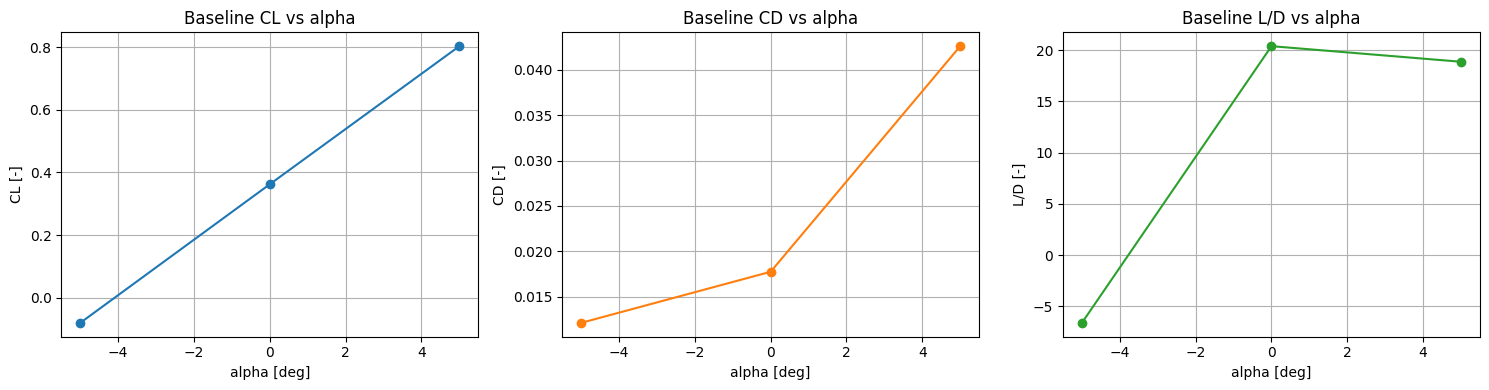

,AoA,CL,CD,CMy,SM,X_np
0,-5.0,-0.080359,0.012151,0.059072,0.087106,0.587487
1,0.0,0.362267,0.017770,0.029615,0.025751,0.566013
2,5.0,0.803099,0.042569,0.027889,-0.028980,0.546857


In [6]:
import matplotlib.pyplot as plt

baseline_aero_df = baseline.to_dataframe().copy()
baseline_stab_df = baseline.stability_dataframe().copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

if not baseline_aero_df.empty:
    axes[0].plot(baseline_aero_df["alpha [deg]"], baseline_aero_df["CL [-]"], marker="o")
    axes[0].set_title("Baseline CL vs alpha")
    axes[0].set_xlabel("alpha [deg]")
    axes[0].set_ylabel("CL [-]")
    axes[0].grid(True)

    axes[1].plot(baseline_aero_df["alpha [deg]"], baseline_aero_df["CD [-]"], marker="o", color="tab:orange")
    axes[1].set_title("Baseline CD vs alpha")
    axes[1].set_xlabel("alpha [deg]")
    axes[1].set_ylabel("CD [-]")
    axes[1].grid(True)

    axes[2].plot(baseline_aero_df["alpha [deg]"], baseline_aero_df["L/D [-]"], marker="o", color="tab:green")
    axes[2].set_title("Baseline L/D vs alpha")
    axes[2].set_xlabel("alpha [deg]")
    axes[2].set_ylabel("L/D [-]")
    axes[2].grid(True)

plt.tight_layout()
plt.show()

if not baseline_stab_df.empty:
    display(
        baseline_stab_df[
            [column for column in ["AoA", "CL", "CD", "CMy", "SM", "X_np"] if column in baseline_stab_df.columns]
        ].round(6)
    )

## CD0 extraction and Raymer cross-check

The baseline run now carries an automatic `CD0` value. The post-processing first fits
`CD = CD0 + k CL^2` from the `.polar` data when available, then falls back to the
already-normalized aerodynamic arrays used by the notebook. The analytical comparison below
uses a Raymer-style wetted-area build-up, so it is mainly a sanity check and a way to see
which geometry assumptions are driving parasite drag.


In [7]:
from vspopt import cd0_design_driver_table, estimate_cd0_breakdown


def build_cd0_geometry_params(model: AircraftModel, results) -> dict:
    """Collect the minimum geometry needed by the Raymer CD0 build-up."""
    re_cref = float(results.re_cref)
    cref = float(results.cref) if np.isfinite(results.cref) and results.cref > 0 else float("nan")

    components = []

    if model.wing is not None:
        # OpenVSP does not expose a single t/c in this model summary, so use a
        # typical small-UAV wing value and keep it visible in the component table.
        components.append(
            {
                "name": "Main wing",
                "type": "wing",
                "area": model.wing.area,
                "characteristic_length": model.wing.mac,
                "t_c": 0.12,
                "Q": 1.0,
            }
        )

    if model.htp is not None:
        components.append(
            {
                "name": "Horizontal tail",
                "type": "tail",
                "area": model.htp.area,
                "characteristic_length": model.htp.mac,
                "t_c": 0.10,
                "Q": 1.05,
            }
        )

    if model.vtp is not None:
        components.append(
            {
                "name": "V-tail / vertical tail",
                "type": "tail",
                "area": model.vtp.area,
                "characteristic_length": model.vtp.mac,
                "t_c": 0.10,
                "Q": 1.05,
            }
        )

    if model.fuselage is not None:
        components.append(
            {
                "name": "Fuselage",
                "type": "fuselage",
                "length": model.fuselage.length,
                "diameter": model.fuselage.max_diameter,
                "fineness_ratio": model.fuselage.fineness_ratio,
                "characteristic_length": model.fuselage.length,
                "Q": 1.1,
            }
        )

    return {
        "S_ref": results.Sref,
        "cref": cref,
        "re_cref": re_cref,
        "mach": results.mach,
        "components": components,
    }


cd0_geometry_params = build_cd0_geometry_params(model, baseline)
cd0_raymer = estimate_cd0_breakdown(cd0_geometry_params)
cd0_openvsp = float(baseline.CD0_estimate)
cd0_analytical = float(cd0_raymer["CD0"])
cd0_delta_pct = (
    100.0 * (cd0_openvsp - cd0_analytical) / abs(cd0_analytical)
    if np.isfinite(cd0_openvsp) and np.isfinite(cd0_analytical) and abs(cd0_analytical) > 1e-12
    else float("nan")
)

cd0_comparison = pd.DataFrame(
    [
        {
            "Parameter": "CD0",
            "OpenVSP": cd0_openvsp,
            "Analytical Raymer": cd0_analytical,
            "Delta %": cd0_delta_pct,
            "Extraction method": baseline.cd0_method,
            "Fit R^2": baseline.cd0_fit_r_squared,
        }
    ]
)

display(cd0_comparison.round(6))

component_table = cd0_raymer["components"].copy()
if not component_table.empty:
    display(component_table.round(6))

if cd0_raymer["warnings"]:
    print("CD0 analytical warnings:")
    for warning in cd0_raymer["warnings"]:
        print(f"  - {warning}")

display(cd0_design_driver_table())


,Parameter,OpenVSP,Analytical Raymer,Delta %,Extraction method,Fit R^2
0,CD0,0.011687,0.018136,-35.558612,CD_vs_CL2_regression,0.99988


,component,type,Cf,FF,Q,S_wet [m^2],Re,CD0 contribution
0,Main wing,wing,0.004603,1.252442,1.00,2.018800,8.500000e+05,0.011876
1,V-tail / vertical tail,tail,0.004909,1.206000,1.05,0.563750,6.071429e+05,0.003576
2,Fuselage,fuselage,0.003587,1.111438,1.10,0.599649,3.400000e+06,0.002683


,rank,variable,effect,why
0,1,Wing thickness-to-chord ratio t/c,Strong,Raises both pressure/form-factor drag and wett...
1,2,Fuselage fineness ratio l/d,Strong,Controls fuselage form factor and pressure rec...
2,3,Surface wetted area,Direct,CD0 scales almost linearly with S_wet / S_ref.
3,4,Transition location / laminar fraction,Large,Changes the skin-friction coefficient Cf.
4,5,Leading-edge radius,Moderate,Affects pressure drag and the usable attached-...


## Wake-node convergence study

Set `RUN_WAKE_CONVERGENCE_STUDY = True` in the configuration cell to run the same baseline case at each value in
`WAKE_NODE_VALUES`. The expected trend is asymptotic: static margin and derivative estimates should move less as the
wake node count increases, while solver time rises. A flat curve can be acceptable after convergence, but a flat curve
at very low wake counts is a warning that the wake discretisation may be masking interference effects.


19:04:46 [WARNING] vspopt.wrapper - wake_iterations=1 is below the OpenVSP/VSPAERO practical minimum; using 3.
19:04:46 [INFO   ] vspopt.wrapper - Running VSPAEROSweep for 'wake_iter_1': alpha=[-5.0, 5.0] deg x 3, Mach=0.120, Re=8.500e+05.
19:10:24 [WARNING] vspopt.vspaero - VSPAEROResults validation issues:
  31 non-finite values found in CL.
  31 non-finite values found in CD.
  31 non-finite values found in LD.
19:10:25 [INFO   ] vspopt.wrapper - Normalizing aerodynamic totals for case 'wake_iter_1' from the .stab file.
19:10:25 [WARNING] vspopt.vspaero - VSPAEROResults validation issues:
  Only 3 alpha points in sweep. Results may be coarse; consider increasing AlphaNpts.
19:10:25 [WARNING] vspopt.vspaero - VSPAEROResults validation issues:
  Only 3 alpha points in sweep. Results may be coarse; consider increasing AlphaNpts.
19:10:26 [WARNING] vspopt.wrapper - wake_iterations=2 is below the OpenVSP/VSPAERO practical minimum; using 3.
19:10:26 [INFO   ] vspopt.wrapper - Running VSPA

,case_name,alpha_points,mach,re_cref,requested_wake_iterations,requested_wake_nodes,wake_iterations,wake_nodes,ld_max,cd_min,...,stab_path,model_path,solver_log_path,sweep_variable,swept_value,tail_x,tail_z,xcg,tail_x_from_cg,tail_z_from_cg
0,wake_iter_1,3,0.12,850000.0,1,3,1,1,20.386443,0.012151,...,C:\Users\gabri\Desktop\TEAM\OpenVspController\...,C:\Users\gabri\Desktop\TEAM\OpenVspController\...,C:\Users\gabri\Desktop\TEAM\OpenVspController\...,wake_iterations,1.0,1.149,0.833,0.557,0.592,-0.003
1,wake_iter_2,3,0.12,850000.0,2,3,2,2,20.386443,0.012151,...,C:\Users\gabri\Desktop\TEAM\OpenVspController\...,C:\Users\gabri\Desktop\TEAM\OpenVspController\...,C:\Users\gabri\Desktop\TEAM\OpenVspController\...,wake_iterations,2.0,1.149,0.833,0.557,0.592,-0.003
2,wake_iter_4,3,0.12,850000.0,4,4,4,4,20.387833,0.012144,...,C:\Users\gabri\Desktop\TEAM\OpenVspController\...,C:\Users\gabri\Desktop\TEAM\OpenVspController\...,C:\Users\gabri\Desktop\TEAM\OpenVspController\...,wake_iterations,4.0,1.149,0.833,0.557,0.592,-0.003
3,wake_iter_8,3,0.12,850000.0,8,8,8,8,20.029266,0.012124,...,C:\Users\gabri\Desktop\TEAM\OpenVspController\...,C:\Users\gabri\Desktop\TEAM\OpenVspController\...,C:\Users\gabri\Desktop\TEAM\OpenVspController\...,wake_iterations,8.0,1.149,0.833,0.557,0.592,-0.003


Wake convergence export files:
  wake_convergence_summary_csv: C:\Users\gabri\Desktop\TEAM\OpenVspController\exports\notebook_20260429_185737\tables\wake_convergence_summary.csv
  wake_convergence_summary_txt: C:\Users\gabri\Desktop\TEAM\OpenVspController\exports\notebook_20260429_185737\tables\wake_convergence_summary.txt
  wake_convergence_aero_csv: C:\Users\gabri\Desktop\TEAM\OpenVspController\exports\notebook_20260429_185737\tables\wake_convergence_aero.csv
  wake_convergence_aero_txt: C:\Users\gabri\Desktop\TEAM\OpenVspController\exports\notebook_20260429_185737\tables\wake_convergence_aero.txt
  wake_convergence_stability_csv: C:\Users\gabri\Desktop\TEAM\OpenVspController\exports\notebook_20260429_185737\tables\wake_convergence_stability.csv
  wake_convergence_stability_txt: C:\Users\gabri\Desktop\TEAM\OpenVspController\exports\notebook_20260429_185737\tables\wake_convergence_stability.txt


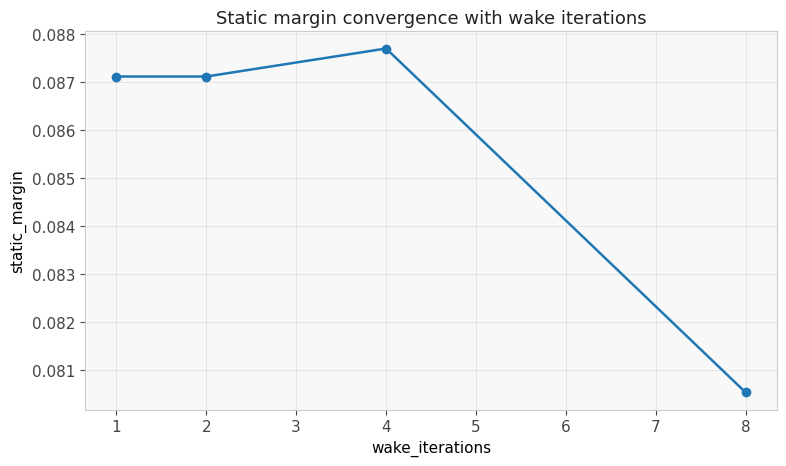

In [8]:
from vspopt import plot_wake_convergence

wake_convergence_results = {}
wake_convergence_metadata = {}
wake_convergence_summary = pd.DataFrame()

if RUN_WAKE_CONVERGENCE_STUDY:
    for wake_iterations in WAKE_NODE_VALUES:
        case_name = f"wake_iter_{int(wake_iterations)}"
        result, metadata = run_named_case(
            case_name,
            sweep_overrides={"wake_iterations": int(wake_iterations)},
            case_group="wake_convergence",
            sweep_variable="wake_iterations",
            swept_value=float(wake_iterations),
        )
        # Store both names because OpenVSP exposes WakeNumIter and NumWakeNodes separately.
        metadata["wake_iterations"] = int(wake_iterations)
        metadata["wake_nodes"] = int(wake_iterations)
        wake_convergence_results[case_name] = result
        wake_convergence_metadata[case_name] = metadata

    wake_convergence_summary = print_case_collection_summary(
        wake_convergence_results,
        wake_convergence_metadata,
    )
    wake_convergence_exports = export_case_collection(
        wake_convergence_results,
        RUN_ROOT / "tables",
        "wake_convergence",
        case_metadata=wake_convergence_metadata,
    )

    fig = plot_wake_convergence(
        wake_convergence_summary,
        metric="static_margin",
        x_col="wake_iterations",
        title="Static margin convergence with wake iterations",
        export_dir=RUN_ROOT / "plots",
        filename="wake_convergence_static_margin",
    )
    display(wake_convergence_summary.round(6))
    print("Wake convergence export files:")
    for key, path in wake_convergence_exports.items():
        print(f"  {key}: {path}")
else:
    print("Wake convergence study skipped. Set RUN_WAKE_CONVERGENCE_STUDY = True to generate the plot automatically.")


## One-at-a-time stability sweeps

The sweep section changes one variable at a time around the baseline state and exports the combined results.
The derived columns `tail_x_from_cg` and `tail_z_from_cg` make it easier to see how the tail location relative
to the center of gravity drives the `.stab` outputs.

In [9]:
BASELINE_SWEEP_VALUES = {
    "Tail X location": BASELINE_GEOMETRY[TAIL_X_KEY],
    "Tail Z location": BASELINE_GEOMETRY[TAIL_Z_KEY],
    "CG X": BASELINE_CG["Xcg"],
}

SWEEP_CASE_DEFINITIONS = {
    "Tail X location": BASELINE_SWEEP_VALUES["Tail X location"] + SWEEP_DELTAS["Tail X location"],
    "Tail Z location": BASELINE_SWEEP_VALUES["Tail Z location"] + SWEEP_DELTAS["Tail Z location"],
    "CG X": BASELINE_SWEEP_VALUES["CG X"] + SWEEP_DELTAS["CG X"],
}

display(
    pd.DataFrame(
        [
            {"variable": label, "values": ", ".join(f"{value:.4f}" for value in values)}
            for label, values in SWEEP_CASE_DEFINITIONS.items()
        ]
    )
)

sweep_results = {}
sweep_metadata = {}

for sweep_variable, values in SWEEP_CASE_DEFINITIONS.items():
    for index, value in enumerate(values, start=1):
        case_name = f"{sweep_variable.lower().replace(' ', '_')}_{index}"
        geometry_updates = None
        sweep_overrides = None

        if sweep_variable == "Tail X location":
            geometry_updates = {TAIL_X_KEY: float(value)}
        elif sweep_variable == "Tail Z location":
            geometry_updates = {TAIL_Z_KEY: float(value)}
        elif sweep_variable == "CG X":
            sweep_overrides = {"xcg": float(value)}
        else:
            raise ValueError(f"Unsupported sweep variable: {sweep_variable}")

        result, metadata = run_named_case(
            case_name,
            geometry_updates=geometry_updates,
            sweep_overrides=sweep_overrides,
            case_group="sweeps",
            sweep_variable=sweep_variable,
            swept_value=float(value),
        )
        sweep_results[case_name] = result
        sweep_metadata[case_name] = metadata

sweep_summary = print_case_collection_summary(sweep_results, sweep_metadata)
sweep_exports = export_case_collection(
    sweep_results,
    RUN_ROOT / "tables",
    "sweep",
    case_metadata=sweep_metadata,
)

print("Sweep export files:")
for key, path in sweep_exports.items():
    print(f"  {key}: {path}")

,variable,values
0,Tail X location,"1.0990, 1.1990"
1,Tail Z location,"0.8030, 0.8630"
2,CG X,"0.5270, 0.5870"


19:33:24 [INFO   ] vspopt.wrapper - Running VSPAEROSweep for 'tail_x_location_1': alpha=[-5.0, 5.0] deg x 3, Mach=0.120, Re=8.500e+05.
19:39:04 [WARNING] vspopt.vspaero - VSPAEROResults validation issues:
  31 non-finite values found in CL.
  31 non-finite values found in CD.
  31 non-finite values found in LD.
19:39:05 [INFO   ] vspopt.wrapper - Normalizing aerodynamic totals for case 'tail_x_location_1' from the .stab file.
19:39:05 [WARNING] vspopt.vspaero - VSPAEROResults validation issues:
  Only 3 alpha points in sweep. Results may be coarse; consider increasing AlphaNpts.
19:39:05 [WARNING] vspopt.vspaero - VSPAEROResults validation issues:
  Only 3 alpha points in sweep. Results may be coarse; consider increasing AlphaNpts.
19:39:07 [INFO   ] vspopt.wrapper - Running VSPAEROSweep for 'tail_x_location_2': alpha=[-5.0, 5.0] deg x 3, Mach=0.120, Re=8.500e+05.
19:44:54 [WARNING] vspopt.vspaero - VSPAEROResults validation issues:
  31 non-finite values found in CL.
  31 non-finite v

,case_name,sweep_variable,swept_value,tail_x,tail_z,xcg,tail_x_from_cg,tail_z_from_cg,ld_max,static_margin,neutral_point_x,has_stab
0,tail_x_location_1,Tail X location,1.099,1.149,0.833,0.557,0.592,-0.003,20.386443,0.087106,0.587487,True
1,tail_x_location_2,Tail X location,1.199,1.149,0.833,0.557,0.592,-0.003,20.386443,0.087106,0.587487,True
2,tail_z_location_1,Tail Z location,0.803,1.149,0.833,0.557,0.592,-0.003,20.386443,0.087106,0.587487,True
3,tail_z_location_2,Tail Z location,0.863,1.149,0.833,0.557,0.592,-0.003,20.386443,0.087106,0.587487,True
4,cg_x_1,CG X,0.527,1.149,0.833,0.527,0.622,-0.003,20.386443,0.174940,0.588229,True
5,cg_x_2,CG X,0.587,1.149,0.833,0.587,0.562,-0.003,20.386443,-0.000729,0.586745,True


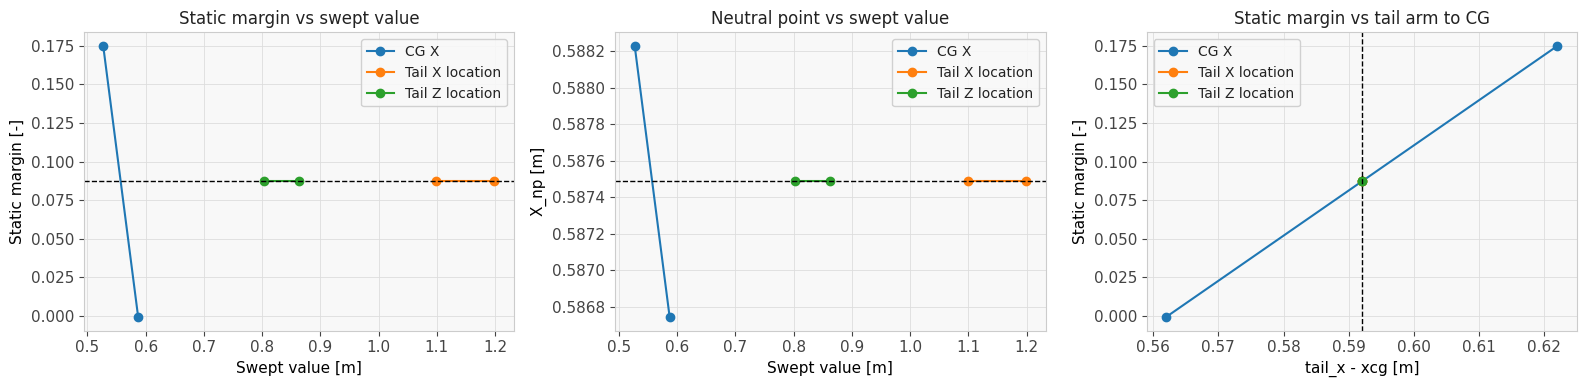

In [10]:
sweep_display_df = sweep_summary[
    [
        column
        for column in [
            "case_name",
            "sweep_variable",
            "swept_value",
            "tail_x",
            "tail_z",
            "xcg",
            "tail_x_from_cg",
            "tail_z_from_cg",
            "ld_max",
            "static_margin",
            "neutral_point_x",
            "has_stab",
        ]
        if column in sweep_summary.columns
    ]
].copy()

display(sweep_display_df.round(6))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
baseline_static_margin = float(baseline.static_margin)
baseline_neutral_point = float(baseline.neutral_point_x)
baseline_tail_arm = float(baseline_meta["tail_x_from_cg"])

for sweep_variable, group in sweep_display_df.groupby("sweep_variable"):
    ordered = group.sort_values("swept_value")
    axes[0].plot(ordered["swept_value"], ordered["static_margin"], marker="o", label=sweep_variable)
    axes[1].plot(ordered["swept_value"], ordered["neutral_point_x"], marker="o", label=sweep_variable)
    axes[2].plot(ordered["tail_x_from_cg"], ordered["static_margin"], marker="o", label=sweep_variable)

axes[0].axhline(baseline_static_margin, color="black", linestyle="--", linewidth=1.0)
axes[0].set_title("Static margin vs swept value")
axes[0].set_xlabel("Swept value [m]")
axes[0].set_ylabel("Static margin [-]")
axes[0].grid(True)
axes[0].legend()

axes[1].axhline(baseline_neutral_point, color="black", linestyle="--", linewidth=1.0)
axes[1].set_title("Neutral point vs swept value")
axes[1].set_xlabel("Swept value [m]")
axes[1].set_ylabel("X_np [m]")
axes[1].grid(True)
axes[1].legend()

axes[2].axvline(baseline_tail_arm, color="black", linestyle="--", linewidth=1.0)
axes[2].set_title("Static margin vs tail arm to CG")
axes[2].set_xlabel("tail_x - xcg [m]")
axes[2].set_ylabel("Static margin [-]")
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

## Wake sensitivity across tail and CG endpoints

This section checks whether wake discretisation is responsible for flat static-margin trends. When
`RUN_WAKE_SENSITIVITY_STUDY` is enabled, the notebook runs only the minimum and maximum values of each existing
Tail X, Tail Z and CG X sweep for every value in `WAKE_NODE_VALUES`. That keeps the study bounded while still
showing the strongest expected variation. Plots are written under `outputs/<session>/wake_sensitivity/`.


20:08:04 [WARNING] vspopt.wrapper - wake_iterations=1 is below the OpenVSP/VSPAERO practical minimum; using 3.
20:08:05 [INFO   ] vspopt.wrapper - Running VSPAEROSweep for 'wake_1_tail_x_1p099': alpha=[-5.0, 5.0] deg x 3, Mach=0.120, Re=8.500e+05.
20:13:26 [WARNING] vspopt.vspaero - VSPAEROResults validation issues:
  31 non-finite values found in CL.
  31 non-finite values found in CD.
  31 non-finite values found in LD.
20:13:27 [INFO   ] vspopt.wrapper - Normalizing aerodynamic totals for case 'wake_1_tail_x_1p099' from the .stab file.
20:13:27 [WARNING] vspopt.vspaero - VSPAEROResults validation issues:
  Only 3 alpha points in sweep. Results may be coarse; consider increasing AlphaNpts.
20:13:27 [WARNING] vspopt.vspaero - VSPAEROResults validation issues:
  Only 3 alpha points in sweep. Results may be coarse; consider increasing AlphaNpts.
20:13:28 [WARNING] vspopt.wrapper - wake_iterations=1 is below the OpenVSP/VSPAERO practical minimum; using 3.
20:13:29 [INFO   ] vspopt.wrappe

,case_name,alpha_points,mach,re_cref,requested_wake_iterations,requested_wake_nodes,wake_iterations,wake_nodes,ld_max,cd_min,...,solver_log_path,sweep_variable,swept_value,tail_x,tail_z,xcg,tail_x_from_cg,tail_z_from_cg,wake_case_family,wake_case_label
0,wake_1_tail_x_1p099,3,0.12,850000.0,1,3,1,1,20.386443,0.012151,...,C:\Users\gabri\Desktop\TEAM\OpenVspController\...,Tail X location,1.099,1.149,0.833,0.557,0.592,-0.003,tail_x,Tail X location = 1.099 m
1,wake_1_tail_x_1p199,3,0.12,850000.0,1,3,1,1,20.386443,0.012151,...,C:\Users\gabri\Desktop\TEAM\OpenVspController\...,Tail X location,1.199,1.149,0.833,0.557,0.592,-0.003,tail_x,Tail X location = 1.199 m
2,wake_1_tail_z_0p803,3,0.12,850000.0,1,3,1,1,20.386443,0.012151,...,C:\Users\gabri\Desktop\TEAM\OpenVspController\...,Tail Z location,0.803,1.149,0.833,0.557,0.592,-0.003,tail_z,Tail Z location = 0.803 m
3,wake_1_tail_z_0p863,3,0.12,850000.0,1,3,1,1,20.386443,0.012151,...,C:\Users\gabri\Desktop\TEAM\OpenVspController\...,Tail Z location,0.863,1.149,0.833,0.557,0.592,-0.003,tail_z,Tail Z location = 0.863 m
4,wake_1_cg_x_0p527,3,0.12,850000.0,1,3,1,1,20.386443,0.012151,...,C:\Users\gabri\Desktop\TEAM\OpenVspController\...,CG X,0.527,1.149,0.833,0.527,0.622,-0.003,cg_x,CG X = 0.527 m
5,wake_1_cg_x_0p587,3,0.12,850000.0,1,3,1,1,20.386443,0.012151,...,C:\Users\gabri\Desktop\TEAM\OpenVspController\...,CG X,0.587,1.149,0.833,0.587,0.562,-0.003,cg_x,CG X = 0.587 m
6,wake_2_tail_x_1p099,3,0.12,850000.0,2,3,2,2,20.386443,0.012151,...,C:\Users\gabri\Desktop\TEAM\OpenVspController\...,Tail X location,1.099,1.149,0.833,0.557,0.592,-0.003,tail_x,Tail X location = 1.099 m
7,wake_2_tail_x_1p199,3,0.12,850000.0,2,3,2,2,20.386443,0.012151,...,C:\Users\gabri\Desktop\TEAM\OpenVspController\...,Tail X location,1.199,1.149,0.833,0.557,0.592,-0.003,tail_x,Tail X location = 1.199 m
8,wake_2_tail_z_0p803,3,0.12,850000.0,2,3,2,2,20.386443,0.012151,...,C:\Users\gabri\Desktop\TEAM\OpenVspController\...,Tail Z location,0.803,1.149,0.833,0.557,0.592,-0.003,tail_z,Tail Z location = 0.803 m
9,wake_2_tail_z_0p863,3,0.12,850000.0,2,3,2,2,20.386443,0.012151,...,C:\Users\gabri\Desktop\TEAM\OpenVspController\...,Tail Z location,0.863,1.149,0.833,0.557,0.592,-0.003,tail_z,Tail Z location = 0.863 m


Wake sensitivity plots saved to: C:\Users\gabri\Desktop\TEAM\OpenVspController\outputs\notebook_20260429_185737\wake_sensitivity
Wake sensitivity export files:
  wake_sensitivity_summary_csv: C:\Users\gabri\Desktop\TEAM\OpenVspController\exports\notebook_20260429_185737\tables\wake_sensitivity_summary.csv
  wake_sensitivity_summary_txt: C:\Users\gabri\Desktop\TEAM\OpenVspController\exports\notebook_20260429_185737\tables\wake_sensitivity_summary.txt
  wake_sensitivity_aero_csv: C:\Users\gabri\Desktop\TEAM\OpenVspController\exports\notebook_20260429_185737\tables\wake_sensitivity_aero.csv
  wake_sensitivity_aero_txt: C:\Users\gabri\Desktop\TEAM\OpenVspController\exports\notebook_20260429_185737\tables\wake_sensitivity_aero.txt
  wake_sensitivity_stability_csv: C:\Users\gabri\Desktop\TEAM\OpenVspController\exports\notebook_20260429_185737\tables\wake_sensitivity_stability.csv
  wake_sensitivity_stability_txt: C:\Users\gabri\Desktop\TEAM\OpenVspController\exports\notebook_20260429_185737\

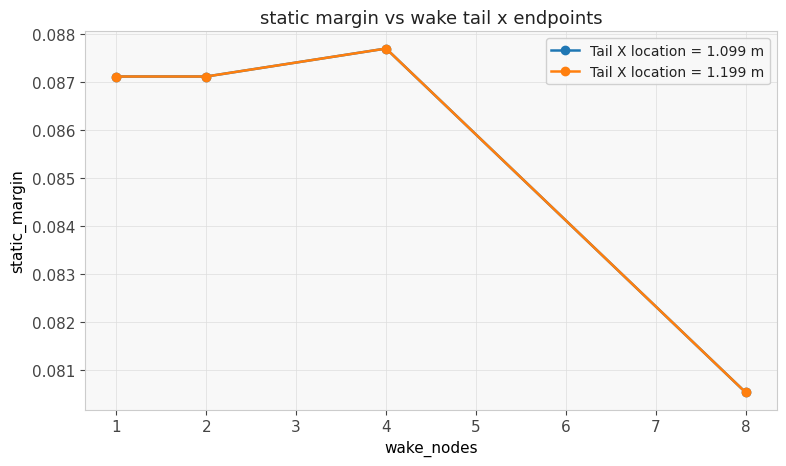

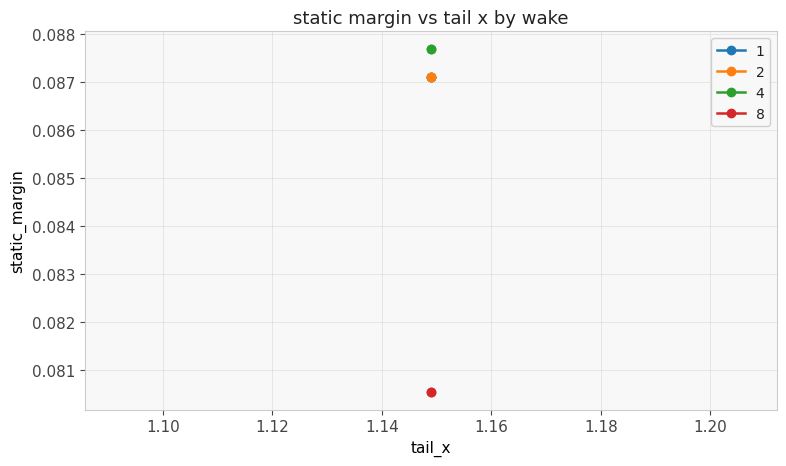

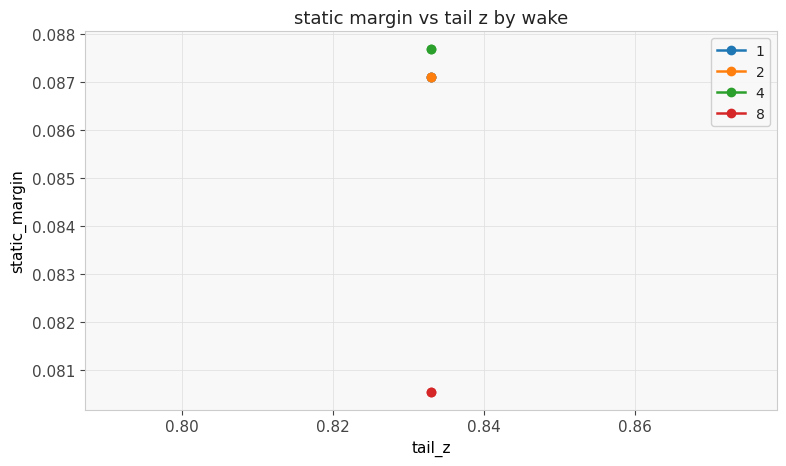

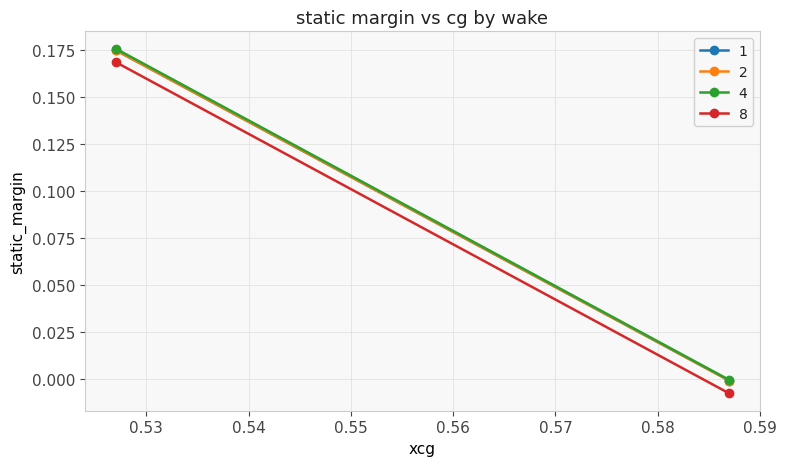

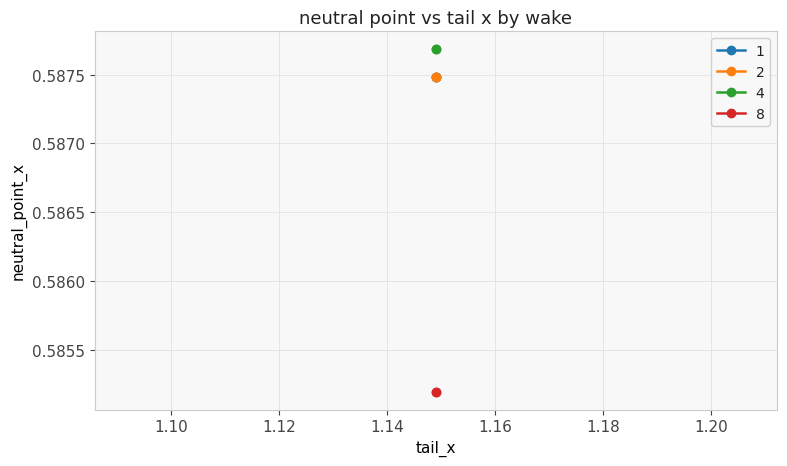

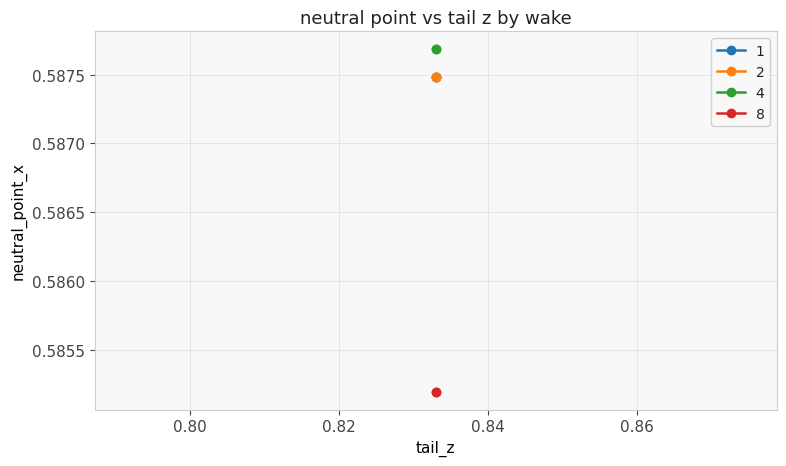

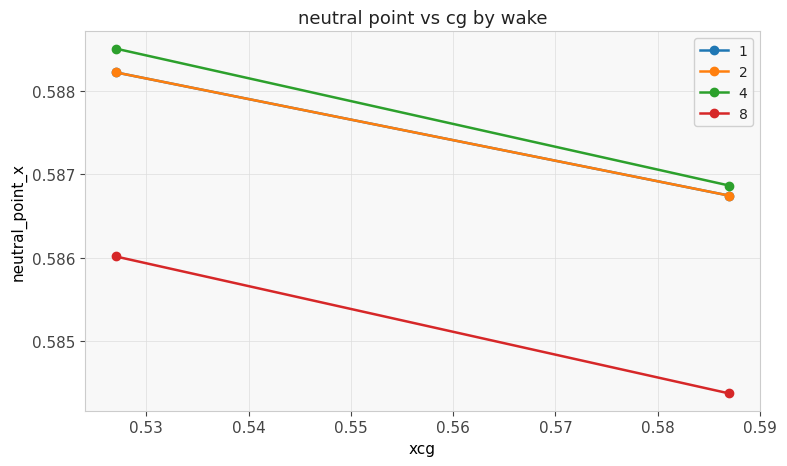

In [11]:
from vspopt import plot_wake_convergence

wake_sensitivity_results = {}
wake_sensitivity_metadata = {}
wake_sensitivity_summary = pd.DataFrame()
WAKE_SENSITIVITY_PLOT_DIR = OUTPUT_ROOT / f"notebook_{SESSION_STAMP}" / "wake_sensitivity"


def endpoint_values(values) -> list[float]:
    """Use only min/max endpoints so the wake study stays computationally affordable."""
    arr = np.asarray(values, dtype=float)
    if arr.size == 0:
        return []
    endpoints = [float(np.nanmin(arr)), float(np.nanmax(arr))]
    return sorted(set(endpoints))


if RUN_WAKE_SENSITIVITY_STUDY:
    wake_study_definitions = {
        "tail_x": {
            "label": "Tail X location",
            "values": endpoint_values(SWEEP_CASE_DEFINITIONS["Tail X location"]),
        },
        "tail_z": {
            "label": "Tail Z location",
            "values": endpoint_values(SWEEP_CASE_DEFINITIONS["Tail Z location"]),
        },
        "cg_x": {
            "label": "CG X",
            "values": endpoint_values(SWEEP_CASE_DEFINITIONS["CG X"]),
        },
    }

    for wake_iterations in WAKE_NODE_VALUES:
        for family, definition in wake_study_definitions.items():
            for value in definition["values"]:
                case_name = f"wake_{int(wake_iterations)}_{family}_{value:.3f}".replace(".", "p")
                geometry_updates = None
                sweep_overrides = {"wake_iterations": int(wake_iterations)}

                if family == "tail_x":
                    geometry_updates = {TAIL_X_KEY: float(value)}
                elif family == "tail_z":
                    geometry_updates = {TAIL_Z_KEY: float(value)}
                elif family == "cg_x":
                    sweep_overrides["xcg"] = float(value)

                result, metadata = run_named_case(
                    case_name,
                    geometry_updates=geometry_updates,
                    sweep_overrides=sweep_overrides,
                    case_group="wake_sensitivity",
                    sweep_variable=definition["label"],
                    swept_value=float(value),
                )
                metadata["wake_iterations"] = int(wake_iterations)
                metadata["wake_nodes"] = int(wake_iterations)
                metadata["wake_case_family"] = family
                metadata["wake_case_label"] = f"{definition['label']} = {value:.3f} m"
                wake_sensitivity_results[case_name] = result
                wake_sensitivity_metadata[case_name] = metadata

    wake_sensitivity_summary = print_case_collection_summary(
        wake_sensitivity_results,
        wake_sensitivity_metadata,
    )
    wake_sensitivity_exports = export_case_collection(
        wake_sensitivity_results,
        RUN_ROOT / "tables",
        "wake_sensitivity",
        case_metadata=wake_sensitivity_metadata,
    )

    plot_specs = [
        ("tail_x", "wake_nodes", "static_margin", "wake_case_label", "static_margin_vs_wake_tail_x_endpoints"),
        ("tail_x", "tail_x", "static_margin", "wake_iterations", "static_margin_vs_tail_x_by_wake"),
        ("tail_z", "tail_z", "static_margin", "wake_iterations", "static_margin_vs_tail_z_by_wake"),
        ("cg_x", "xcg", "static_margin", "wake_iterations", "static_margin_vs_cg_by_wake"),
        ("tail_x", "tail_x", "neutral_point_x", "wake_iterations", "neutral_point_vs_tail_x_by_wake"),
        ("tail_z", "tail_z", "neutral_point_x", "wake_iterations", "neutral_point_vs_tail_z_by_wake"),
        ("cg_x", "xcg", "neutral_point_x", "wake_iterations", "neutral_point_vs_cg_by_wake"),
    ]

    for family, x_col, metric, group_col, filename in plot_specs:
        plot_df = wake_sensitivity_summary[wake_sensitivity_summary["wake_case_family"] == family]
        plot_wake_convergence(
            plot_df,
            metric=metric,
            x_col=x_col,
            group_col=group_col,
            title=filename.replace("_", " "),
            export_dir=WAKE_SENSITIVITY_PLOT_DIR,
            filename=filename,
        )

    display(wake_sensitivity_summary.round(6))
    print("Wake sensitivity plots saved to:", WAKE_SENSITIVITY_PLOT_DIR)
    print("Wake sensitivity export files:")
    for key, path in wake_sensitivity_exports.items():
        print(f"  {key}: {path}")
else:
    print("Wake sensitivity study skipped. Set RUN_WAKE_SENSITIVITY_STUDY = True to generate endpoint wake plots.")


Read the saved figures by looking for curve collapse as wake iterations increase. If Tail X, Tail Z or CG curves
remain flat for all wake settings, the trend is probably geometric or due to the stability formulation. If the curves
separate at low wake counts and settle at higher counts, use the first settled wake value as the default for later sweeps.


* **Centro di Gravità ($X_{cg}$):** Il punto dove agisce il peso. È la variabile di controllo principale per l'assetto del velivolo.
* **Punto Neutro ($X_{np}$):** È il "centro aerodinamico" dell'intero aereo. È il punto rispetto al quale il momento aerodinamico non varia al variare dell'angolo d'attacco ($\alpha$).
    * **Formula:** $X_{np}$ si ricava dalla condizione $\frac{dC_m}{d\alpha} = 0$.
* **Margine Statico ($SM$):** Rappresenta quanto l'aereo è "intrinsecamente" stabile. Indica la distanza tra il Punto Neutro e il Baricentro, normalizzata rispetto alla corda media aerodinamica ($c$).
    * **Formula:** $SM = \frac{X_{np} - X_{cg}}{c}$

1.  **Spostamento del Baricentro:** Spostando il baricentro ($X_{cg}$) in avanti, il **Margine Statico aumenta**. Questo comportamento è corretto: più il peso è avanzato rispetto al "perno" aerodinamico ($X_{np}$), più l'aereo manifesta una tendenza naturale a tornare in equilibrio dopo una perturbazione.
2.  **Geometria della Coda:** Spostando la coda all'indietro, il **Punto Neutro ($X_{np}$)** si sposta a sua volta verso poppa. Questo risultato è teoricamente coerente: una coda con un braccio maggiore esercita una "leva" superiore, spostando il centro di pressione totale dell'intero velivolo verso il fondo.

## Analytical stability checks

The table below compares first-order analytical estimates against the values parsed from OpenVSP. The formulas use
standard Helmbold/DATCOM-style approximations, so a warning means "inspect this difference" rather than "stop the
workflow". The downwash gradient is included as an analytical diagnostic even though VSPAERO does not report a direct
single scalar value for it in the current `.stab` file.


In [12]:
import warnings

from vspopt import compare_analytical_to_openvsp, run_basic_stability_checks
from vspopt.postprocess import first_finite_value


def safe_model_param(key: tuple[str, str, str], default: float = float("nan")) -> float:
    """Read an OpenVSP parameter without making the analytical section brittle."""
    try:
        return float(wrapper.get_param(*key))
    except Exception:
        return float(default)


def build_stability_check_inputs() -> dict[str, float]:
    """Collect geometry and flight-condition inputs for the analytical checks."""
    tail = model.htp if model.htp is not None else model.vtp
    mac = float(baseline.cref) if np.isfinite(baseline.cref) and baseline.cref > 0 else model.wing.mac
    wing_x_le = safe_model_param(("WingGeom", "X_Location", "XForm"), default=0.0)
    tail_x_le = float(BASELINE_GEOMETRY[TAIL_X_KEY])

    wing_ac_x = wing_x_le + 0.25 * model.wing.mac
    tail_ac_x = tail_x_le + 0.25 * tail.mac if tail is not None else float("nan")
    tail_area_ratio = tail.area / model.wing.area if tail is not None and model.wing.area > 0 else float("nan")

    return {
        "mach": baseline.mach,
        "mac": mac,
        "x_cg": BASELINE_CG["Xcg"],
        "wing_aspect_ratio": model.wing.aspect_ratio,
        "wing_sweep_quarter_chord_deg": model.wing.sweep_le,
        "wing_ac_x": wing_ac_x,
        "tail_aspect_ratio": tail.aspect_ratio if tail is not None else float("nan"),
        "tail_sweep_quarter_chord_deg": tail.sweep_le if tail is not None else float("nan"),
        "tail_area_ratio": tail_area_ratio,
        "tail_ac_x": tail_ac_x,
        "tail_efficiency": 0.9,
        "downwash_tail_efficiency": 1.0,
    }


analytical_inputs = build_stability_check_inputs()
analytical_values = run_basic_stability_checks(analytical_inputs)
openvsp_values = {
    "Static margin Kn [-]": baseline.static_margin,
    "Neutral point x_np [m]": baseline.neutral_point_x,
    "CM_alpha [1/rad]": first_finite_value(baseline.stability_records, "CMy_Alpha"),
    "CL_alpha [1/rad]": first_finite_value(baseline.stability_records, "CL_Alpha"),
    "Downwash d_epsilon/d_alpha [-]": float("nan"),
}

with warnings.catch_warnings(record=True) as analytical_warnings:
    warnings.simplefilter("always", RuntimeWarning)
    analytical_comparison = compare_analytical_to_openvsp(
        analytical_values,
        openvsp_values,
        warning_threshold_pct=15.0,
        emit_warnings=True,
    )

display(pd.DataFrame([analytical_inputs]).round(6))
display(analytical_comparison.round(6))

if analytical_warnings:
    print("Analytical check warnings:")
    for warning in analytical_warnings:
        print(f"  - {warning.message}")


,mach,mac,x_cg,wing_aspect_ratio,wing_sweep_quarter_chord_deg,wing_ac_x,tail_aspect_ratio,tail_sweep_quarter_chord_deg,tail_area_ratio,tail_ac_x,tail_efficiency,downwash_tail_efficiency
0,0.12,0.35,0.557,8.0,0.0,0.5475,4.4,0.0,0.280612,1.2115,0.9,1.0


,Parameter,Analytical,OpenVSP,Delta %,Warning
0,Static margin Kn [-],0.192037,0.087106,120.463909,|Delta| > 15%
1,Neutral point x_np [m],0.624213,0.587487,6.251350,
2,CM_alpha [1/rad],-1.029975,-0.434956,-136.799707,|Delta| > 15%
3,CL_alpha [1/rad],5.363415,4.993418,7.409692,
4,Downwash d_epsilon/d_alpha [-],0.377497,NaN,NaN,OpenVSP reference unavailable


Analytical check warnings:
  - Static margin Kn [-]: |Delta| > 15%
  - CM_alpha [1/rad]: |Delta| > 15%
  - Downwash d_epsilon/d_alpha [-]: OpenVSP reference unavailable


## Optimization setup

The optimization section reuses the same validated variables as the sweep section.
`Xcg` is validated with the exact OpenVSP name, but the optimizer applies it back to `run_vspaero_sweep`
through the corrected Python keyword mapping, so the first half of the notebook and the optimization module now
use the same variable names consistently.

In [13]:
from vspopt import ObjectiveSpec, compare_results, run_bayesian_optimization, run_gradient_optimization, run_two_phase_optimization

reference_ld = float(baseline.LD_max) if np.isfinite(baseline.LD_max) else float("nan")
objective_constraints = []
if np.isfinite(reference_ld):
    objective_constraints.append(("LD_max", ">=", reference_ld * 0.95))

objective = ObjectiveSpec(
    metrics=[("static_margin", -1.0), ("LD_max", -0.05)],
    constraints=objective_constraints,
)

optimization_sweep_kwargs = dict(BASELINE_ANALYSIS)
optimization_sweep_kwargs.update(
    {
        "working_dir": RUN_ROOT / "optimization_evals",
        "output_stem": "opt_eval",
        "control_surface_deflections": dict(BASELINE_CONTROL_DEFLECTIONS),
    }
)

print("Objective metrics:", objective.metrics)
print("Objective constraints:", objective.constraints)
display(validate_design_variables(wrapper, DESIGN_VARIABLES))

Objective metrics: [('static_margin', -1.0), ('LD_max', -0.05)]
Objective constraints: [('LD_max', '>=', 19.36712127180641)]


,label,kind,target,initial,lower,upper,units,status,detail
0,Tail X location,geometry,Vtail/XForm/X_Location,1.149,1.069,1.229,m,ok,Vtail/XForm/X_Location = 1.149
1,Tail Z location,geometry,Vtail/XForm/Z_Location,0.833,0.793,0.873,m,ok,Vtail/XForm/Z_Location = 0.833
2,CG X,analysis_input,VSPAEROSweep/Xcg,0.557,0.517,0.597,m,ok,VSPAEROSweep/Xcg
3,available_control_groups,info,"Ailerons, Ruddervators",NaN,NaN,NaN,,info,Detected control-surface groups in the loaded ...


In [14]:
restore_baseline_state()
gradient_result = run_gradient_optimization(
    wrapper, 
    DESIGN_VARIABLES, # design variables are respectively Tail X location, Tail Z location, and CG X location
    objective, # we want to maximize static margin and L/D, with a constraint to keep L/D within 5% of the baseline value
    sweep_kwargs=optimization_sweep_kwargs,
    options=OPTIMIZATION_SETTINGS["gradient_options"],
)

display(pd.DataFrame([gradient_result.summary_series()]).round(6))

23:05:19 [INFO   ] vspopt.optimization - Starting gradient-based optimization (SLSQP) with 3 design variables.
23:05:19 [INFO   ] vspopt.wrapper - Running VSPAEROSweep for 'opt_eval': alpha=[-5.0, 5.0] deg x 3, Mach=0.120, Re=8.500e+05.
23:10:48 [WARNING] vspopt.vspaero - VSPAEROResults validation issues:
  31 non-finite values found in CL.
  31 non-finite values found in CD.
  31 non-finite values found in LD.
23:10:49 [INFO   ] vspopt.wrapper - Normalizing aerodynamic totals for case 'opt_eval' from the .stab file.
23:10:49 [WARNING] vspopt.vspaero - VSPAEROResults validation issues:
  Only 3 alpha points in sweep. Results may be coarse; consider increasing AlphaNpts.
23:10:49 [WARNING] vspopt.vspaero - VSPAEROResults validation issues:
  Only 3 alpha points in sweep. Results may be coarse; consider increasing AlphaNpts.
23:10:51 [INFO   ] vspopt.wrapper - Running VSPAEROSweep for 'opt_eval': alpha=[-5.0, 5.0] deg x 3, Mach=0.120, Re=8.500e+05.
23:16:17 [WARNING] vspopt.vspaero - VSP

,method,n_evals,best_obj,elapsed [s],converged,LD_max,CD_at_LD,CL_at_LD,CDmin,CD_min,...,CD0_estimate,CD0_fit,CL_alpha,static_margin,StaticMargin,neutral_point_x,NeutralPointX,x_Tail X location,x_Tail Z location,x_CG X
0,Gradient-based (SLSQP),8,-1.223541,2600.6,True,20.3864,0.0178,0.3623,0.0122,0.0122,...,0.0117,0.0117,0.0883,0.2042,0.2042,0.5885,0.5885,1.149,0.833,0.517


In [15]:
restore_baseline_state()
bayesian_result = run_bayesian_optimization(
    wrapper,
    DESIGN_VARIABLES,
    objective,
    sweep_kwargs=optimization_sweep_kwargs,
    n_trials=OPTIMIZATION_SETTINGS["bayesian_trials"],
    seed=OPTIMIZATION_SETTINGS["seed"],
    show_progress=False,
)

display(pd.DataFrame([bayesian_result.summary_series()]).round(6))

23:54:19 [INFO   ] vspopt.optimization - Starting Bayesian optimization (4 trials, 10 startup).
23:54:21 [INFO   ] vspopt.wrapper - Running VSPAEROSweep for 'opt_eval': alpha=[-5.0, 5.0] deg x 3, Mach=0.120, Re=8.500e+05.
23:59:51 [WARNING] vspopt.vspaero - VSPAEROResults validation issues:
  31 non-finite values found in CL.
  31 non-finite values found in CD.
  31 non-finite values found in LD.
23:59:51 [INFO   ] vspopt.wrapper - Normalizing aerodynamic totals for case 'opt_eval' from the .stab file.
23:59:51 [WARNING] vspopt.vspaero - VSPAEROResults validation issues:
  Only 3 alpha points in sweep. Results may be coarse; consider increasing AlphaNpts.
23:59:51 [WARNING] vspopt.vspaero - VSPAEROResults validation issues:
  Only 3 alpha points in sweep. Results may be coarse; consider increasing AlphaNpts.
23:59:54 [INFO   ] vspopt.wrapper - Running VSPAEROSweep for 'opt_eval': alpha=[-5.0, 5.0] deg x 3, Mach=0.120, Re=8.500e+05.
00:07:50 [WARNING] vspopt.vspaero - VSPAEROResults val

,method,n_evals,best_obj,elapsed [s],converged,LD_max,CD_at_LD,CL_at_LD,CDmin,CD_min,...,CD0_estimate,CD0_fit,CL_alpha,static_margin,StaticMargin,neutral_point_x,NeutralPointX,x_Tail X location,x_Tail Z location,x_CG X
0,Bayesian (Optuna TPE),4,-1.187001,1625.1,True,20.3864,0.0178,0.3623,0.0122,0.0122,...,0.0117,0.0117,0.0883,0.1677,0.1677,0.5882,0.5882,1.1648,0.8055,0.5295


00:26:45 [INFO   ] vspopt.optimization - === Two-phase optimization: Phase 1 (Bayesian) ===
00:26:45 [INFO   ] vspopt.optimization - Starting Bayesian optimization (4 trials, 10 startup).


  0%|          | 0/4 [00:00<?, ?it/s]

00:26:47 [INFO   ] vspopt.wrapper - Running VSPAEROSweep for 'opt_eval': alpha=[-5.0, 5.0] deg x 3, Mach=0.120, Re=8.500e+05.
00:31:56 [WARNING] vspopt.vspaero - VSPAEROResults validation issues:
  31 non-finite values found in CL.
  31 non-finite values found in CD.
  31 non-finite values found in LD.
00:31:56 [INFO   ] vspopt.wrapper - Normalizing aerodynamic totals for case 'opt_eval' from the .stab file.
00:31:56 [WARNING] vspopt.vspaero - VSPAEROResults validation issues:
  Only 3 alpha points in sweep. Results may be coarse; consider increasing AlphaNpts.
00:31:56 [WARNING] vspopt.vspaero - VSPAEROResults validation issues:
  Only 3 alpha points in sweep. Results may be coarse; consider increasing AlphaNpts.
00:31:57 [INFO   ] vspopt.wrapper - Running VSPAEROSweep for 'opt_eval': alpha=[-5.0, 5.0] deg x 3, Mach=0.120, Re=8.500e+05.
00:37:57 [WARNING] vspopt.vspaero - VSPAEROResults validation issues:
  31 non-finite values found in CL.
  31 non-finite values found in CD.
  31 non

,n_evals,best_obj,elapsed [s],converged,LD_max,CD_at_LD,CL_at_LD,CDmin,CD_min,CD0,CD0_estimate,CD0_fit,CL_alpha,static_margin,StaticMargin,neutral_point_x,NeutralPointX,x_Tail X location,x_Tail Z location,x_CG X
method,,,,,,,,,,,,,,,,,,,,
Gradient-based (SLSQP),8,-1.223541,2600.6,True,20.3864,0.0178,0.3623,0.0122,0.0122,0.0117,0.0117,0.0117,0.0883,0.2042,0.2042,0.5885,0.5885,1.1490,0.8330,0.5170
Bayesian (Optuna TPE),4,-1.187001,1625.1,True,20.3864,0.0178,0.3623,0.0122,0.0122,0.0117,0.0117,0.0117,0.0883,0.1677,0.1677,0.5882,0.5882,1.1648,0.8055,0.5295
Gradient-based (SLSQP),8,-1.223541,2649.5,True,20.3864,0.0178,0.3623,0.0122,0.0122,0.0117,0.0117,0.0117,0.0883,0.2042,0.2042,0.5885,0.5885,1.1648,0.8055,0.5170


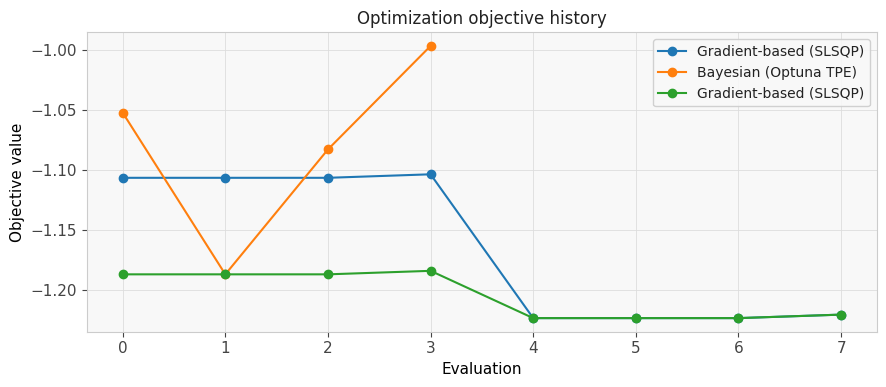

In [16]:
restore_baseline_state()
two_phase_bayesian, two_phase_slsqp = run_two_phase_optimization(
    wrapper,
    DESIGN_VARIABLES,
    objective,
    sweep_kwargs=optimization_sweep_kwargs,
    n_bayesian_trials=OPTIMIZATION_SETTINGS["two_phase_bayesian_trials"],
    slsqp_options=OPTIMIZATION_SETTINGS["gradient_options"],
    seed=OPTIMIZATION_SETTINGS["seed"],
)

optimizer_comparison = compare_results([gradient_result, bayesian_result, two_phase_slsqp])
display(optimizer_comparison.round(6))

fig, ax = plt.subplots(figsize=(9, 4))
for result in [gradient_result, bayesian_result, two_phase_slsqp]:
    ax.plot(result.history_obj, marker="o", label=result.method)
ax.set_title("Optimization objective history")
ax.set_xlabel("Evaluation")
ax.set_ylabel("Objective value")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

Il sistema confronta tre approcci per raggiungere il Margine Statico target:

* **SLSQP:** Algoritmo basato su gradiente. Estremamente efficiente per convergere rapidamente verso il minimo locale più vicino.
* **Bayesian (TPE):** Metodo probabilistico ideale per esplorare lo spazio di design. I "picchi" nel grafico di convergenza rappresentano fasi di **esplorazione**, in cui l'algoritmo verifica zone meno note per evitare minimi locali errati.
* **Two-Phase:** Rappresenta lo stato dell'arte del tool; utilizza la ricerca Bayesiana per localizzare la regione ottimale e la rifinisce con SLSQP per la massima precisione numerica.


In [17]:
restore_baseline_state()
optimized_sweep_kwargs = two_phase_slsqp.apply_best(
    wrapper,
    sweep_kwargs={
        **BASELINE_ANALYSIS,
        "control_surface_deflections": dict(BASELINE_CONTROL_DEFLECTIONS),
    },
)
optimized = wrapper.run_vspaero_sweep(
    working_dir=RUN_ROOT / "optimized",
    output_stem="optimized_two_phase",
    **optimized_sweep_kwargs,
)
optimized_metadata = build_case_metadata("optimized_two_phase", sweep_variable="optimizer")

comparison_cases = {
    "baseline_reference": baseline,
    "optimized_two_phase": optimized,
}
comparison_metadata = {
    "baseline_reference": baseline_meta,
    "optimized_two_phase": optimized_metadata,
}
comparison_exports = export_case_collection(
    comparison_cases,
    RUN_ROOT / "tables",
    "baseline_vs_optimized",
    case_metadata=comparison_metadata,
)

print("Baseline vs optimized export files:")
for key, path in comparison_exports.items():
    print(f"  {key}: {path}")

performance_comparison = pd.DataFrame(
    {
        "baseline_reference": baseline.performance_summary(),
        "optimized_two_phase": optimized.performance_summary(),
    }
)
display(performance_comparison.round(6))

display(optimized.stability_dataframe().round(6))

01:45:03 [INFO   ] vspopt.wrapper - Running VSPAEROSweep for 'optimized_two_phase': alpha=[-5.0, 5.0] deg x 3, Mach=0.120, Re=8.500e+05.
01:50:50 [WARNING] vspopt.vspaero - VSPAEROResults validation issues:
  31 non-finite values found in CL.
  31 non-finite values found in CD.
  31 non-finite values found in LD.
01:50:51 [INFO   ] vspopt.wrapper - Normalizing aerodynamic totals for case 'optimized_two_phase' from the .stab file.
01:50:51 [WARNING] vspopt.vspaero - VSPAEROResults validation issues:
  Only 3 alpha points in sweep. Results may be coarse; consider increasing AlphaNpts.
01:50:51 [WARNING] vspopt.vspaero - VSPAEROResults validation issues:
  Only 3 alpha points in sweep. Results may be coarse; consider increasing AlphaNpts.
Baseline vs optimized export files:
  baseline_vs_optimized_summary_csv: C:\Users\gabri\Desktop\TEAM\OpenVspController\exports\notebook_20260429_185737\tables\baseline_vs_optimized_summary.csv
  baseline_vs_optimized_summary_txt: C:\Users\gabri\Desktop\T

,baseline_reference,optimized_two_phase
Case,baseline_reference,optimized_two_phase
Mach,0.12,0.12
Re_cref,850000.0,850000.0
requested_wake_iterations,3,3
requested_wake_nodes,3,3
wake_iterations,3,3
wake_nodes,3,3
Sref [m^2],0.98,0.98
bref [m],2.8,2.8
cref [m],0.35,0.35


,Sref,Cref,Bref,Xcg,Ycg,Zcg,Mach_cond,AoA,Beta_cond,Rho,...,CMm_Mach,CMm_U,CMn,CMn_Alpha,CMn_Beta,CMn_p,CMn_q,CMn_r,CMn_Mach,CMn_U
0,0.98,0.35,2.8,0.517,0.0,0.836,0.12,-5.0,0.0,1.225,...,0.004077,0.000489,0.000238,0.001530,0.064625,0.071812,-0.011136,-0.048465,0.000384,0.000046
1,0.98,0.35,2.8,0.517,0.0,0.836,0.12,0.0,0.0,1.225,...,0.001199,0.000144,0.000017,-0.001138,0.058498,-0.019269,-0.006364,-0.044819,0.000037,0.000004
2,0.98,0.35,2.8,0.517,0.0,0.836,0.12,5.0,0.0,1.225,...,0.007023,0.000843,0.000040,0.001581,0.076118,-0.107822,0.008810,-0.055363,0.000040,0.000005
